### load

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.validation import check_is_fitted
from category_encoders import CountEncoder

%matplotlib inline

from add_features import add_modified_features

In [2]:
train = pl.read_csv('../data/train.csv',infer_schema_length=None,null_values='NA')
test = pl.read_csv('../data/test.csv',infer_schema_length=None,null_values = 'NA')

print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [3]:
# filter outlier
outlier_ids = [250,314,336,524,707,1299]  # 確認した外れ値のId
train = train.filter(~pl.col('Id').is_in(outlier_ids))

X = train.select(cs.exclude('SalePrice'))
y = train['SalePrice']

X_test = test.select(cs.exclude('SalePrice'))
X.glimpse()

Rows: 1454
Columns: 80
$ Id            <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ MSSubClass    <i64> 60, 20, 60, 70, 60, 50, 20, 60, 50, 190
$ MSZoning      <str> 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RM', 'RL'
$ LotFrontage   <i64> 65, 80, 68, 60, 84, 85, 75, null, 51, 50
$ LotArea       <i64> 8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420
$ Street        <str> 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave'
$ Alley         <str> null, null, null, null, null, null, null, null, null, null
$ LotShape      <str> 'Reg', 'Reg', 'IR1', 'IR1', 'IR1', 'IR1', 'Reg', 'IR1', 'Reg', 'Reg'
$ LandContour   <str> 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl'
$ Utilities     <str> 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub'
$ LotConfig     <str> 'Inside', 'FR2', 'Inside', 'Corner', 'FR2', 'Inside', 'Inside', 'Corner', 'Inside', 'Corner'
$ LandSlope     <str> 'Gtl', 'Gtl

### explore

In [4]:
train.describe()

statistic,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,f64
"""count""",1454.0,1454.0,"""1454""",1198.0,1454.0,"""1454""","""91""","""1454""","""1454""","""1454""","""1454""","""1454""","""1454""","""1454""","""1454""","""1454""","""1454""",1454.0,1454.0,1454.0,1454.0,"""1454""","""1454""","""1454""","""1454""","""1446""",1446.0,"""1454""","""1454""","""1454""","""1417""","""1417""","""1416""","""1417""",1454.0,"""1416""",…,1454.0,1454.0,1454.0,1454.0,1454.0,1454.0,1454.0,1454.0,1454.0,"""1454""",1454.0,"""1454""",1454.0,"""764""","""1373""",1373.0,"""1373""",1454.0,1454.0,"""1373""","""1373""","""1454""",1454.0,1454.0,1454.0,1454.0,1454.0,1454.0,"""6""","""281""","""52""",1454.0,1454.0,1454.0,"""1454""","""1454""",1454.0
"""null_count""",0.0,0.0,"""0""",256.0,0.0,"""0""","""1363""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""8""",8.0,"""0""","""0""","""0""","""37""","""37""","""38""","""37""",0.0,"""38""",…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""690""","""81""",81.0,"""81""",0.0,0.0,"""81""","""81""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""1448""","""1173""","""1402""",0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",731.155433,56.856946,null,69.730384,10038.881706,null,null,null,null,null,null,null,null,null,null,null,null,6.093535,5.575653,1971.235901,1984.834938,null,null,null,null,null,102.46888,null,null,null,null,null,null,null,437.007565,null,…,346.116919,5.868638,1509.263411,0.421596,0.057084,1.562586,0.383081,2.865887,1.046768,null,6.510316,null,0.60729,null,null,1978.504006,null,1.765475,471.856259,null,null,null,93.621045,46.272352,22.044704,3.423659,15.123109,2.440165,null,null,null,42.843191,6.322558,2007.816369,null,null,180617.088033
"""std""",421.723882,42.220998,null,23.097012,5416.551558,null,null,null,null,null,null,null,null,null,null,null,null,1.377551,1.114003,30.232411,20.644675,null,null,null,null,null,179.267742,null,null,null,null,null,null,null,431.996658,null,…,435.709642,48.721916,507.999021,0.514458,0.23794,0.55017,0.503001,0.816573,0.220772,null,1.617043,null,0.638716,null,null,24.706458,null,0.748031,212.396539,null,null,null,124.334031,65.366141,61.228893,29.376979,55.864001,38.262292,null,null,null,496.697866,2.703484,1.329938,null,null,79327.264105
"""min""",1.0,20.0,"""C (all)""",21.0,1300.0,"""Grvl""","""Grvl""","""IR1""","""Bnk""","""AllPub""","""Corner""","""Gtl""","""Blmngtn""","""Artery""","""Artery""","""1Fam""","""1.5Fin""",1.0,1.0,1872.0,1950.0,"""Flat""","""CompShg""","""AsbShng""","""AsbShng""","""BrkCmn""",0.0,"""Ex""","""Ex""","""BrkTil""","""Ex""","""Fa""","""Av""","""ALQ""",0.0,"""ALQ""",…,0.0,0.0,334.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""",2.0,"""Maj1""",0.0,"""Ex""","""2Types""",1900.0,"""Fin""",0.0,0.0,"""Ex""","""Ex""","""N""",0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""","""GdPrv""","""Gar2""",0.0,1.0,2006.0,"""COD""","""Abnorml""",34900.0
"""25%""",367.0,20.0,null,59.0,7535.0,null,null,n

In [5]:
nulls = train.select(cs.numeric()).to_pandas().isna().sum()
nulls[nulls > 0]

LotFrontage    256
MasVnrArea       8
GarageYrBlt     81
dtype: int64

### pipeline

In [6]:
from preprocess import build_target_transformer, build_preprocessor

log_standardize_y = build_target_transformer()
preprocessor = build_preprocessor()

### add modified -> drop useless -> filter outlier ->train test split

In [7]:
# add modified
X = add_modified_features(X)
X_test = add_modified_features(X_test)

# drop useless
drop_feats = [
    'Id',
    '2ndFlrSF',
    '1stFlrSF',
    'GrLivArea',
    'Exterior1st',
    'Exterior2nd',
    'TotalBsmtSF',
    'GarageCars',
    'TotalFlrSF',
    'YearBuilt',
    'OverallQual',
    'BsmtFullBath',
]
X = X.select(cs.exclude(drop_feats))
X_test = X_test.select(cs.exclude(drop_feats))

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
feat_corr = X_train.select(cs.numeric()).to_pandas().corr()

corr_threshold = 0.8

# 上三角だけを使って、同じ組み合わせの重複と自己相関(対角)を除外
corr_pairs = (
    feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "corr"]

high_corr_pairs = (
    corr_pairs.loc[corr_pairs["corr"].abs() > corr_threshold]
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs

,feature_1,feature_2,corr
0,YearRemodAdd,RemodAge,-0.997922
1,GarageYrBlt,BuildingAge,-0.823798
2,BsmtUnfSF,BsmtFnRatio,-0.819596
3,BsmtFinSF1,BsmtFnRatio,0.802123


### Ridge

c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values

Fold 1: train RMSLE = 0.1022 / valid RMSLE = 0.1178
Fold 2: train RMSLE = 0.1042 / valid RMSLE = 0.1130
Fold 3: train RMSLE = 0.1000 / valid RMSLE = 0.1291
Fold 4: train RMSLE = 0.1034 / valid RMSLE = 0.1162
Fold 5: train RMSLE = 0.1016 / valid RMSLE = 0.1198
CV平均: train 0.1023 / valid 0.1192
最終スコア(test RMSLE): 0.1180


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


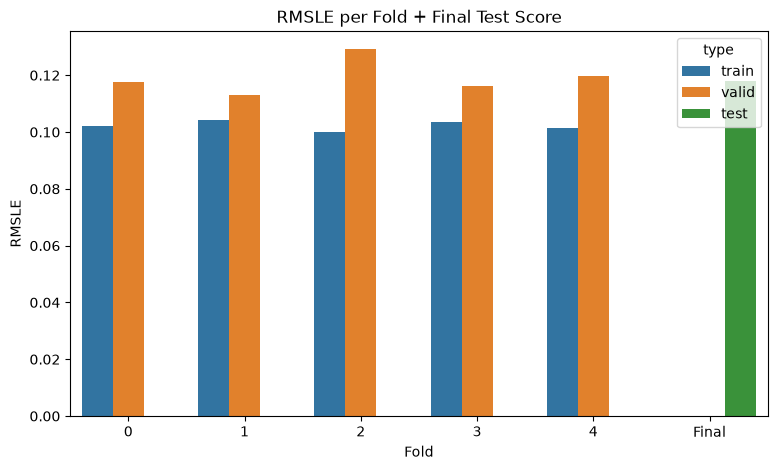

In [14]:
N_SELECT_FEATS = 30

base_model = Pipeline([
    ("prep", preprocessor),
    # ("select", SelectFromModel(Ridge(alpha=1.0), max_features=N_SELECT_FEATS, threshold=-np.inf)),
    ("ridge", Ridge(alpha=1.0))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


<Axes: xlabel='SalePrice', ylabel='Error'>

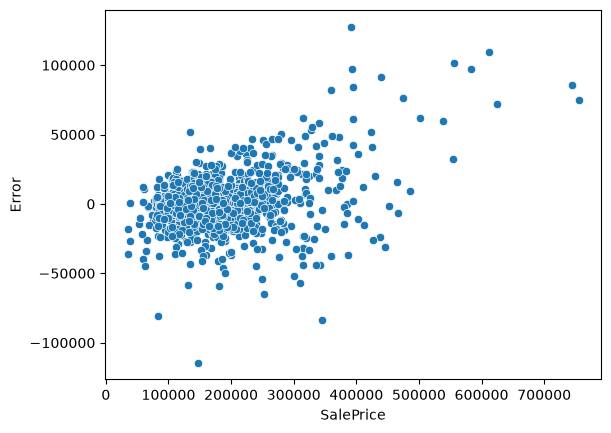

In [15]:
# Target vs Ridge predict error
ridge_err = y_train - model.predict(X_train)
err_df = pl.DataFrame({
    "SalePrice":y_train,
    "Error":ridge_err
})
sns.scatterplot(err_df,x='SalePrice',y='Error')


<Axes: ylabel='Count'>

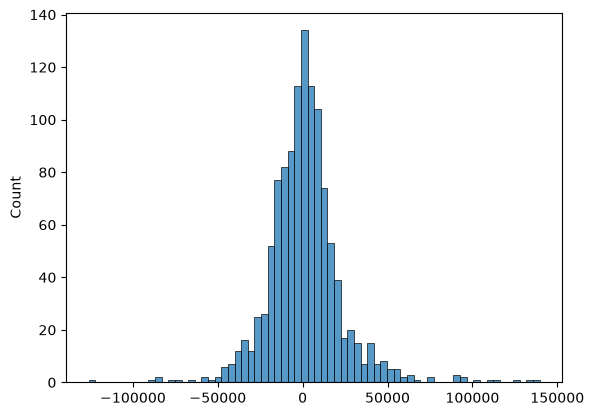

In [11]:
sns.histplot(ridge_err)

### grid search(Ridge)

In [16]:
alpha_candidates = [0.1, 1.0, 10.0, 100.0, 300.0]

# selectステップ(特徴量選択用Ridge)とridgeステップ(最終回帰用Ridge)のalphaを連動させて探索
param_grid = [
    {
        # "regressor__select__estimator__alpha": [alpha],
        "regressor__ridge__alpha": [alpha],
    }
    for alpha in alpha_candidates
]

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSLE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_score_gs = root_mean_squared_log_error(y_va, best_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs:.4f}")

# alphaごとのCVスコア一覧
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__ridge__alpha")
cv_results


Best params: {'regressor__ridge__alpha': 10.0}
Best CV RMSLE: 0.1180
最終スコア(test RMSLE): 0.1174


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,param_regressor__ridge__alpha,mean_test_score,std_test_score,mean_test_RMSLE
0,0.1,-0.119542,0.005376,0.119542
1,1.0,-0.119185,0.005446,0.119185
2,10.0,-0.117966,0.005323,0.117966
3,100.0,-0.118024,0.005309,0.118024
4,300.0,-0.121966,0.005771,0.121966


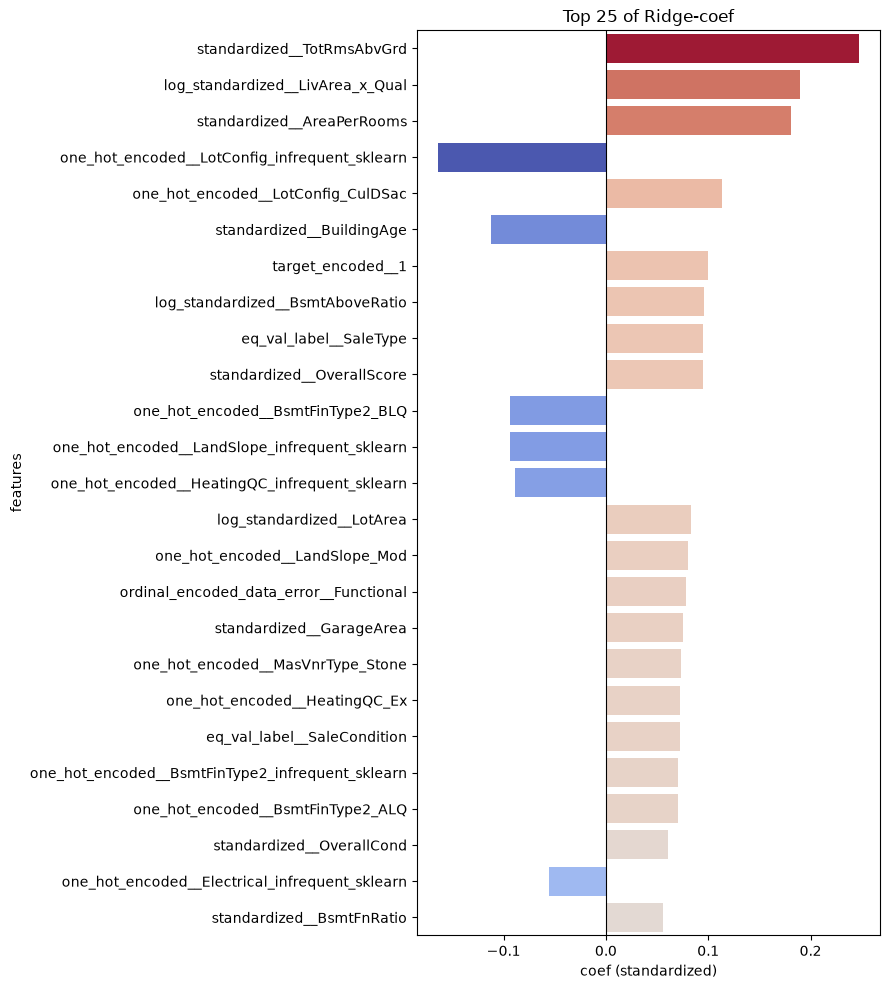

In [17]:
# 特徴量の寄与度（Ridge係数）トップ25
all_feature_names = model.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask = model.regressor_.named_steps["select"].get_support()
feature_names = all_feature_names  # [selected_mask]
coefs = model.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True)

importance_df = importance_df.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("features")
plt.tight_layout()

plt.show()


### XGBoost

In [18]:
def make_xgb(**xgb_params):
    base_model_xgb = Pipeline([
        ("prep", preprocessor),
        ("xgb", XGBRegressor(**xgb_params)),
    ])
    return TransformedTargetRegressor(
        regressor=base_model_xgb,
        transformer=log_standardize_y,
        check_inverse=False
    )

XGB_PARAMS = dict(
    n_estimators=2000,  # early stoppingが上限を決めるため大きめに設定
    learning_rate=0.01,
    max_leaves=15,
    max_depth=5,
    min_child_weight=50,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    importance_type='gain',
    early_stopping_rounds=50,
    eval_metric="rmse",
)

def fit_xgb_with_early_stopping(X_tr, y_tr, X_val, y_val, **xgb_params):
    """PipelineのprepとTransformedTargetRegressorの変換を手動で適用し、eval_setにearly stoppingを効かせる"""
    model = make_xgb(**xgb_params)
    prep = model.regressor.named_steps["prep"]
    xgb = model.regressor.named_steps["xgb"]

    y_tr_t = log_standardize_y.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
    y_val_t = log_standardize_y.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

    # prep内のTargetEncoderがyを要求するため、生のy_trを渡す
    X_tr_t = prep.fit_transform(X_tr, y_tr)
    X_val_t = prep.transform(X_val)

    xgb.fit(X_tr_t, y_tr_t, eval_set=[(X_val_t, y_val_t)], verbose=False)

    # 学習済みprep/xgbをそのままPipeline/TransformedTargetRegressorに差し込む
    model.regressor_ = model.regressor
    model.transformer_ = log_standardize_y
    model._training_dim = 1  # predict()内部で参照されるためfit()を通さない分手動設定
    return model

model_xgb = fit_xgb_with_early_stopping(X_train, y_train, X_va, y_va, **XGB_PARAMS)
best_iteration_xgb = model_xgb.regressor_.named_steps["xgb"].best_iteration
print(f"best_iteration: {best_iteration_xgb}")

test_score_xgb = root_mean_squared_log_error(y_va, model_xgb.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_xgb:.4f}")


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


best_iteration: 1149
最終スコア(test RMSLE): 0.1238


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


### grid search (XGBoost)

In [19]:
param_dist_xgb = {
    "regressor__xgb__n_estimators": [500, 800],
    "regressor__xgb__learning_rate": [0.02, 0.03, 0.05],
    "regressor__xgb__max_leaves": [5, 7],
    "regressor__xgb__max_depth": [3, 4],
    "regressor__xgb__min_child_weight": [30, 50, 70, 100],
    "regressor__xgb__reg_alpha": [0.01, 0.05, 0.1],
    "regressor__xgb__reg_lambda": [1.0, 2.0, 5.0, 10.0],
    "regressor__xgb__subsample": [0.5, 0.6, 0.7],
    "regressor__xgb__colsample_bytree": [0.5, 0.6, 0.7],
}

# early_stopping_rounds付きだとeval_setが必須になりCVと相性が悪いため、探索用は早期終了なしのモデルを使う
search_model_xgb = make_xgb(**{k: v for k, v in XGB_PARAMS.items() if k not in ("early_stopping_rounds", "eval_metric")})

random_search_xgb = RandomizedSearchCV(
    estimator=search_model_xgb,
    param_distributions=param_dist_xgb,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=40,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_xgb.fit(X_train, y_train)

print(f"Best params: {random_search_xgb.best_params_}")
print(f"Best CV RMSLE: {-random_search_xgb.best_score_:.4f}")

# 探索で見つかったベストパラメータでearly stoppingを使い最終学習し直す
best_xgb_params = {
    k.replace("regressor__xgb__", ""): v
    for k, v in random_search_xgb.best_params_.items()
}
best_model_xgb = fit_xgb_with_early_stopping(
    X_train, y_train, X_va, y_va,
    **{**XGB_PARAMS, **best_xgb_params},
)
print(f"best_iteration: {best_model_xgb.regressor_.named_steps['xgb'].best_iteration}")

test_score_gs_xgb = root_mean_squared_log_error(y_va, best_model_xgb.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_xgb:.4f}")

# パラメータごとのCVスコア一覧
cv_results_xgb = pd.DataFrame(random_search_xgb.cv_results_)[
    [
        "param_regressor__xgb__n_estimators",
        "param_regressor__xgb__learning_rate",
        "param_regressor__xgb__max_leaves",
        "param_regressor__xgb__max_depth",
        "param_regressor__xgb__min_child_weight",
        "param_regressor__xgb__reg_alpha",
        "param_regressor__xgb__reg_lambda",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_xgb.sort_values('mean_test_RMSLE',ascending=True).head(15)

c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best params: {'regressor__xgb__subsample': 0.5, 'regressor__xgb__reg_lambda': 1.0, 'regressor__xgb__reg_alpha': 0.1, 'regressor__xgb__n_estimators': 800, 'regressor__xgb__min_child_weight': 30, 'regressor__xgb__max_leaves': 5, 'regressor__xgb__max_depth': 4, 'regressor__xgb__learning_rate': 0.05, 'regressor__xgb__colsample_bytree': 0.6}
Best CV RMSLE: 0.1254


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


best_iteration: 303
最終スコア(test RMSLE): 0.1218


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,param_regressor__xgb__n_estimators,param_regressor__xgb__learning_rate,param_regressor__xgb__max_leaves,param_regressor__xgb__max_depth,param_regressor__xgb__min_child_weight,param_regressor__xgb__reg_alpha,param_regressor__xgb__reg_lambda,mean_test_score,std_test_score,mean_test_RMSLE
20,800,0.05,5,4,30,0.10,1.0,-0.125377,0.006791,0.125377
22,800,0.05,5,3,30,0.05,10.0,-0.125388,0.006829,0.125388
25,500,0.03,7,4,30,0.10,5.0,-0.125465,0.007702,0.125465
32,800,0.03,5,3,30,0.05,1.0,-0.125761,0.007715,0.125761
12,800,0.02,5,3,30,0.01,1.0,-0.125792,0.007323,0.125792
3,500,0.03,5,4,30,0.01,5.0,-0.126183,0.006601,0.126183
0,800,0.02,7,3,30,0.10,10.0,-0.126281,0.007581,0.126281
17,500,0.03,5,3,30,0.10,5.0,-0.126347,0.006889,0.126347
21,500,0.03,5,4,30,0.10,1.0,-0.126788,0.006945,0.126788
31,800,0.05,5,4,50,0.05,2.0,-0.127097,0.006585,0.127097


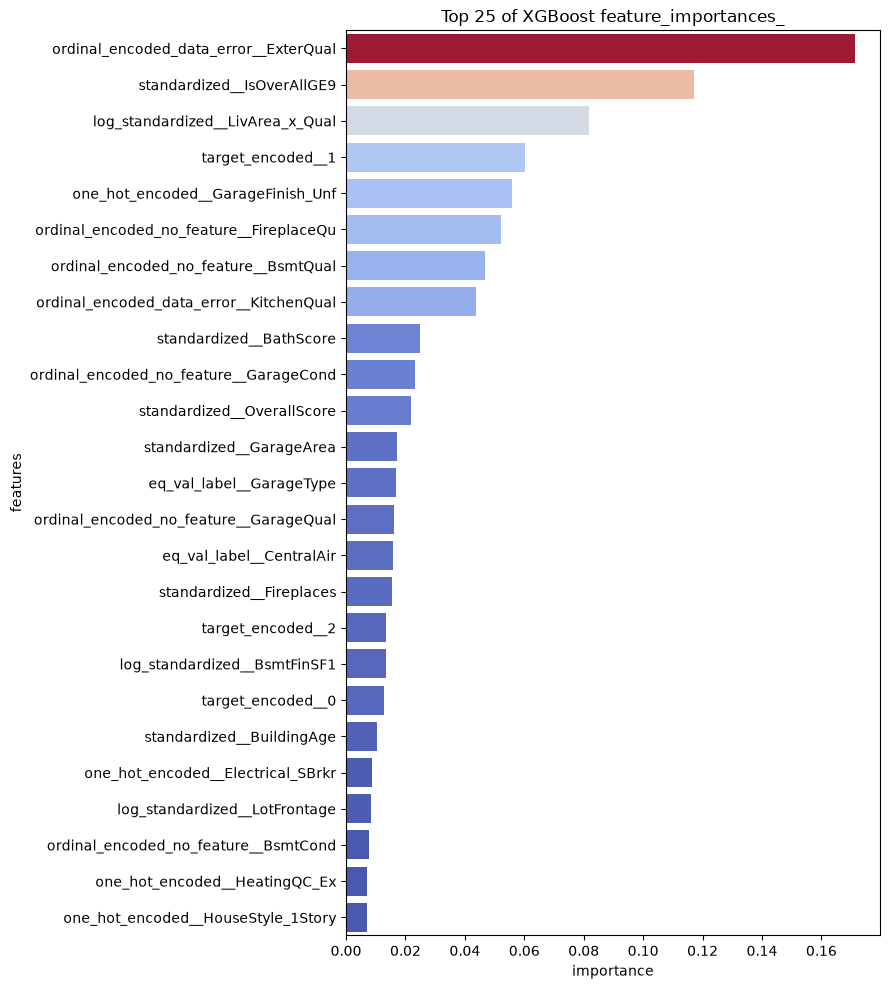

In [20]:
# 特徴量の寄与度（XGBoost feature_importances_）トップ25
all_feature_names_xgb = best_model_xgb.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask_xgb = best_model_xgb.regressor_.named_steps["select"].get_support()
feature_names_xgb = all_feature_names_xgb  # [selected_mask_xgb]
importances_xgb = best_model_xgb.regressor_.named_steps["xgb"].feature_importances_

importance_df_xgb = pl.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb,
}).sort("importance", descending=True)

importance_df_xgb = importance_df_xgb.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df_xgb.to_pandas(),
    x="importance", y="feature",
    hue="importance", palette="coolwarm", dodge=False, legend=False,
)
plt.title("Top 25 of XGBoost feature_importances_")
plt.xlabel("importance")
plt.ylabel("features")
plt.tight_layout()

plt.show()


### SVR (kernel=rbf)

In [21]:
base_model_svr = Pipeline([
    ("prep", preprocessor),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05,
        gamma=0.001,
    ))
])
model_svr = TransformedTargetRegressor(
    regressor=base_model_svr,
    transformer=log_standardize_y,
    check_inverse=False
)

result_svr = cross_validate(
    model_svr, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_svr = -result_svr["train_score"]
valid_scores_svr = -result_svr["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_svr, valid_scores_svr), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_svr.mean():.4f} / valid {valid_scores_svr.mean():.4f}")

model_svr.fit(X_train, y_train)
test_score_svr = root_mean_squared_log_error(y_va, model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_svr:.4f}")

c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values

Fold 1: train RMSLE = 0.0886 / valid RMSLE = 0.1127
Fold 2: train RMSLE = 0.0896 / valid RMSLE = 0.1089
Fold 3: train RMSLE = 0.0844 / valid RMSLE = 0.1243
Fold 4: train RMSLE = 0.0898 / valid RMSLE = 0.1124
Fold 5: train RMSLE = 0.0868 / valid RMSLE = 0.1195
CV平均: train 0.0878 / valid 0.1156
最終スコア(test RMSLE): 0.1110


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


### grid search (SVR)

In [22]:
param_dist_svr = {
    "regressor__svr__C": [0.5, 1.0, 3.0, 5.0, 10.0],
    "regressor__svr__epsilon": [0.01, 0.02, 0.05],
    "regressor__svr__gamma": [0.0005, 0.001, 0.005, 0.01],
}

random_search_svr = RandomizedSearchCV(
    estimator=model_svr,
    param_distributions=param_dist_svr,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=100,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_svr.fit(X_train, y_train)

print(f"Best params: {random_search_svr.best_params_}")
print(f"Best CV RMSLE: {-random_search_svr.best_score_:.4f}")

best_model_svr = random_search_svr.best_estimator_
test_score_gs_svr = root_mean_squared_log_error(y_va, best_model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_svr:.4f}")

# パラメータごとのCVスコア一覧
cv_results_svr = pd.DataFrame(random_search_svr.cv_results_)[
    [
        "param_regressor__svr__C",
        "param_regressor__svr__epsilon",
        "param_regressor__svr__gamma",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_svr.sort_values('mean_test_RMSLE',ascending=True).head(15)

c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 60 is smaller than n_iter=100. Running 60 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best params: {'regressor__svr__gamma': 0.001, 'regressor__svr__epsilon': 0.05, 'regressor__svr__C': 10.0}
Best CV RMSLE: 0.1156
最終スコア(test RMSLE): 0.1110


,param_regressor__svr__C,param_regressor__svr__epsilon,param_regressor__svr__gamma,mean_test_score,std_test_score,mean_test_RMSLE
57,10.0,0.05,0.0010,-0.115559,0.005562,0.115559
53,10.0,0.02,0.0010,-0.115781,0.005800,0.115781
49,10.0,0.01,0.0010,-0.116007,0.005923,0.116007
56,10.0,0.05,0.0005,-0.116502,0.006192,0.116502
45,5.0,0.05,0.0010,-0.116554,0.006318,0.116554
52,10.0,0.02,0.0005,-0.116646,0.006209,0.116646
41,5.0,0.02,0.0010,-0.116656,0.006639,0.116656
37,5.0,0.01,0.0010,-0.116904,0.006598,0.116904
48,10.0,0.01,0.0005,-0.116976,0.006234,0.116976
33,3.0,0.05,0.0010,-0.117651,0.006842,0.117651


### stacking

c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values

Fold 1: train RMSLE = 0.1014 / valid RMSLE = 0.1171
Fold 2: train RMSLE = 0.0975 / valid RMSLE = 0.1089
Fold 3: train RMSLE = 0.0866 / valid RMSLE = 0.1270
Fold 4: train RMSLE = 0.1072 / valid RMSLE = 0.1179
Fold 5: train RMSLE = 0.0980 / valid RMSLE = 0.1162
CV平均: train 0.0981 / valid 0.1174


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


最終スコア(test RMSLE): 0.1159


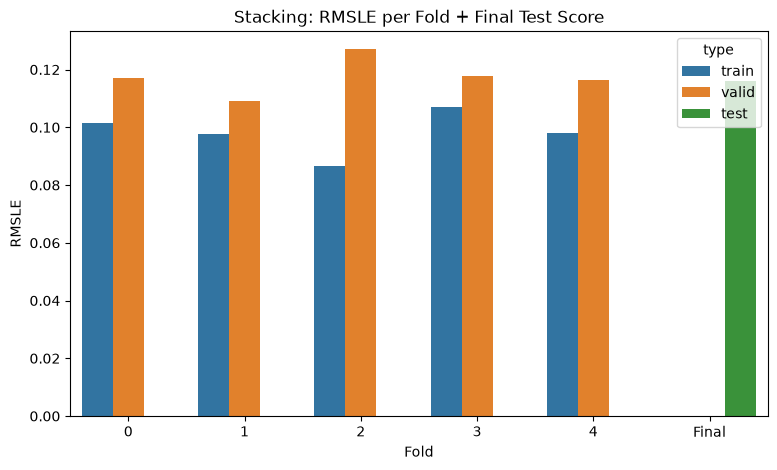

In [24]:
from sklearn.ensemble import StackingRegressor

# StackingRegressor/cross_validateは内部でクローンして再fitするため、
# early_stopping_rounds付きのbest_model_xgbはeval_setなしでエラーになる。
# best_iterationで木の本数を固定した早期終了なしのXGBoostを代わりに使う。
stacking_xgb_params = {
    k: v for k, v in {**XGB_PARAMS, **best_xgb_params}.items()
    if k not in ("early_stopping_rounds", "eval_metric")
}
stacking_xgb_params["n_estimators"] = best_model_xgb.regressor_.named_steps["xgb"].best_iteration + 1
stacking_xgb_estimator = make_xgb(**stacking_xgb_params)

stacking_model = StackingRegressor(
    estimators=[
        ("ridge", best_model),
        ("xgb", stacking_xgb_estimator),
        ("svr", best_model_svr),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=cv,
    n_jobs=-1,
    passthrough=False,
)

result_stack = cross_validate(
    stacking_model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_stack = -result_stack["train_score"]
valid_scores_stack = -result_stack["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_stack, valid_scores_stack), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_stack.mean():.4f} / valid {valid_scores_stack.mean():.4f}")

stacking_model.fit(X_train, y_train)
test_score_stack = root_mean_squared_log_error(y_va, stacking_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_stack:.4f}")

# スコアグラフ
df_stack = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores_stack) + list(valid_scores_stack) + [test_score_stack],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df_stack, x="Fold", y="RMSLE", hue="type")

plt.title("Stacking: RMSLE per Fold + Final Test Score")
plt.show()

### submit

In [25]:
from sklearn.base import clone

# ベストハイパーパラメータのRidge/XGBoost/SVRをベース推定器としたスタッキングモデルを
# 全学習データ(X, y)で最終学習
final_stacking_model = clone(stacking_model)
final_stacking_model.fit(X, y)

pred_final = final_stacking_model.predict(X_test)

submit_df = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": pred_final
})


c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\tak\Documents\Projects\Kaggle\house-prices\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['LuxuryCount']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [26]:
submit_df.write_csv("../submit.csv")

### submit (Ridgeのみ)

In [ ]:
from sklearn.base import clone

# Ridgeベストパラメータのみで全学習データ(X, y)を再学習
final_ridge_model = clone(best_model)
final_ridge_model.fit(X, y)

pred_final_ridge = final_ridge_model.predict(X_test)

submit_df_ridge = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": pred_final_ridge
})

submit_df_ridge.write_csv("../submit_ridge.csv")
